In [2]:
import subprocess
import sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap'])

0

In [3]:
# CELLULE 1 - Imports et chargement
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance

COLOR_BLUE  = "#163767"
COLOR_RED   = "#E53935"
COLOR_GREEN = "#43A047"

# Chargement des données
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test  = np.load('../data/processed/y_test.npy')

# Chargement du meilleur modele
xgb = joblib.load('../models/xgboost.joblib')

# Noms des features
FEATURE_NAMES = ['vibration_rms', 'temperature_motor', 'current_phase_avg',
                 'pressure_level', 'rpm', 'hours_since_maintenance', 
                 'ambient_temp', 'machine_type_CNC', 'machine_type_Compressor',
                 'machine_type_Pump', 'machine_type_Robotic Arm',
                 'operating_mode_idle', 'operating_mode_normal', 
                 'operating_mode_peak']

print(f"Modele charge : {type(xgb).__name__}")
print(f"Features : {len(FEATURE_NAMES)}")

Modele charge : XGBClassifier
Features : 14


On prend le meilleur modèle (XGBoost)
→ On l'analyse pour comprendre POURQUOI il prédit ce qu'il prédit

"Pourquoi tu dis que cette machine va tomber en panne ?"

Le modèle ne peut pas répondre tout seul  , il fait juste des calculs !
→ C'est pour ça qu'on a besoin de Feature Importance et SHAP pour traduire ses calculs en langage humain.

Feature Importance → "en général, quelles variables comptent le plus ?"
SHAP               → "pour CETTE machine, pourquoi cette décision ?"

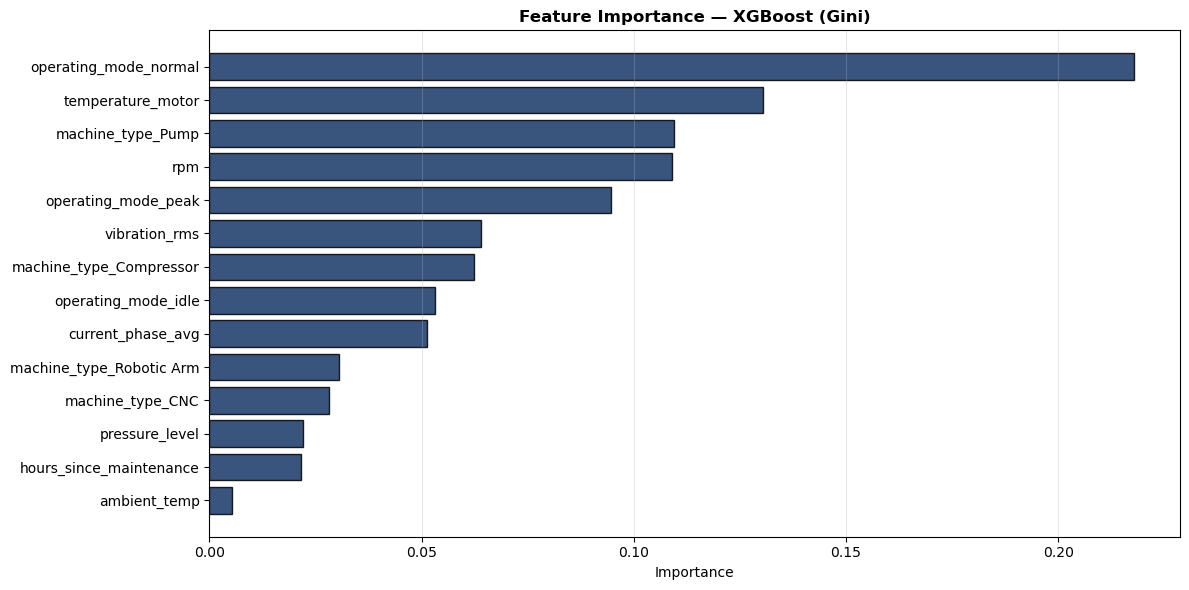

Top 5 features les plus importantes :
  1. operating_mode_normal : 0.2178
  2. temperature_motor : 0.1304
  3. machine_type_Pump : 0.1094
  4. rpm : 0.1091
  5. operating_mode_peak : 0.0946


In [4]:
# CELLULE 2 - Feature Importance native XGBoost
importances = xgb.feature_importances_
indices = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh([FEATURE_NAMES[i] for i in indices[::-1]], 
               importances[indices[::-1]], 
               color=COLOR_BLUE, edgecolor='black', alpha=0.85)
ax.set_title('Feature Importance — XGBoost (Gini)', fontweight='bold') #gini = mesure à quel point une variable aide à séparer les pannes des machines saines
ax.set_xlabel('Importance')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/feature_importance_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 features les plus importantes :")
for i in range(5):
    print(f"  {i+1}. {FEATURE_NAMES[indices[i]]} : {importances[indices[i]]:.4f}")

C'est quoi feature_importances_ ?
C'est une propriété intégrée dans XGBoost — pas besoin de la calculer manuellement !
Après le fit, XGBoost mémorise automatiquement quelle variable a été la plus utile pour prendre ses décisions.
pythonxgb.feature_importances_
→ [0.2178, 0.1304, 0.1094, 0.1091, 0.0946, 0.0640, 0.0620...]
→ C'est un tableau de 14 valeurs une par variable

Pourquoi XGBoost l'utilise le plus ?
XGBoost construit des arbres de décision.
À chaque fois qu'il cherche une règle pour diviser les données :
Question 1 : operating_mode_normal = 1 ou 0 ?
→ Sépare 60% des données d'un coup !
→ Très utile pour diviser rapidement

Question 2 : temperature_motor > 70°C ?
→ Sépare moins de données
→ Moins utilisé statistiquement

On complète cette analyse avec SHAP pour une interprétation plus fiable.

SHAP = SHapley Additive exPlanations
C'est une technique mathématique qui explique pourquoi le modèle a pris une décision

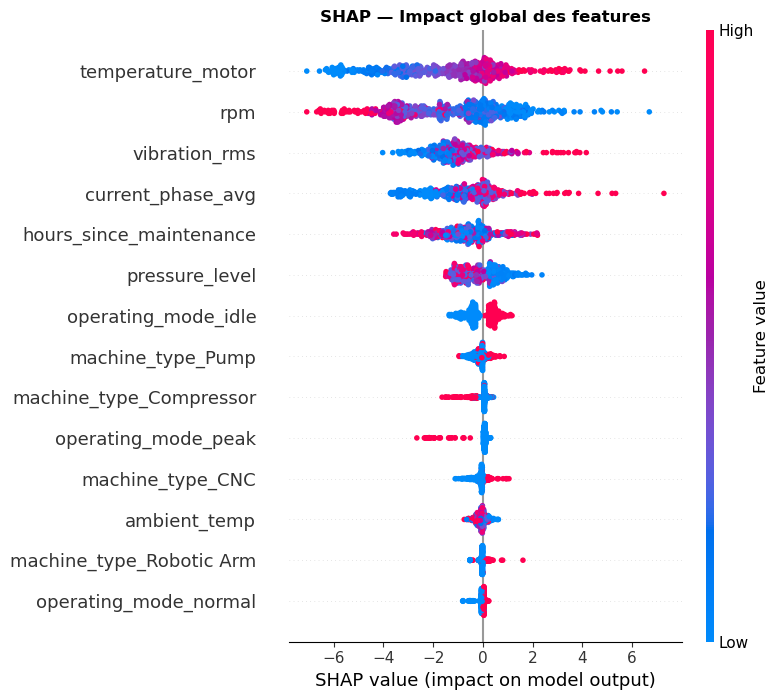

In [5]:
# CELLULE 3 - SHAP Values
explainer = shap.TreeExplainer(xgb)  #On crée un "expliqueur" spécialement conçu pour les modèles à arbres comme XGBoost = Il connaît la structure interne du modèle
shap_values = explainer.shap_values(X_test[:500]) # 500 lignes = suffisant pour avoir une bonne représentation

# Summary plot global
fig, ax = plt.subplots(figsize=(12, 7))
shap.summary_plot(shap_values, X_test[:500], 
                  feature_names=FEATURE_NAMES,
                  show=False)
plt.title('SHAP — Impact global des features', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
shap_mean = np.abs(shap_values).mean(axis=0)
for name, val in sorted(zip(FEATURE_NAMES, shap_mean), key=lambda x: x[1], reverse=True):
    print(f"{name:35s} : {val:.4f}")

temperature_motor                   : 2.0809
rpm                                 : 2.0544
vibration_rms                       : 1.2976
current_phase_avg                   : 1.1934
hours_since_maintenance             : 0.9723
pressure_level                      : 0.6588
operating_mode_idle                 : 0.4841
machine_type_Pump                   : 0.2169
machine_type_Compressor             : 0.2067
operating_mode_peak                 : 0.1882
machine_type_CNC                    : 0.1755
ambient_temp                        : 0.1439
machine_type_Robotic Arm            : 0.0791
operating_mode_normal               : 0.0714


temperature_motor      : 2.08  ← N°1 ! Signal thermique principal
rpm                    : 2.05  ← N°2 ! Vitesse anormale = surcharge
vibration_rms          : 1.30  ← N°3 ! Vibrations anormales
current_phase_avg      : 1.19  ← N°4 ! Courant électrique élevé
hours_since_maintenance: 0.97  ← N°5 ! Longtemps sans maintenance
pressure_level         : 0.66  ← N°6 ! Pression anormale


Les valeurs SHAP confirment que les 4 capteurs physiques temperature_motor, RPM, vibration_rms et current_phase_avg sont les vrais signaux de panne avec des impacts entre 1.19 et 2.08. SHAP corrige la Feature Importance — operating_mode_normal qui était en tête avec 0.2178 n'a en réalité qu'un impact de 0.07. C'est la puissance de SHAP : donner une interprétation plus juste et plus exploitable métie

La cellule 4 produit deux graphiques. Le premier montre l'importance globale SHAP en barres 
Le second montre SHAP pour la machine la plus à risque  , on voit exactement quels capteurs déclenchent l'alerte. 
C'est ce qu'on appelle l'explicabilité locale — expliquer une prédiction individuelle.


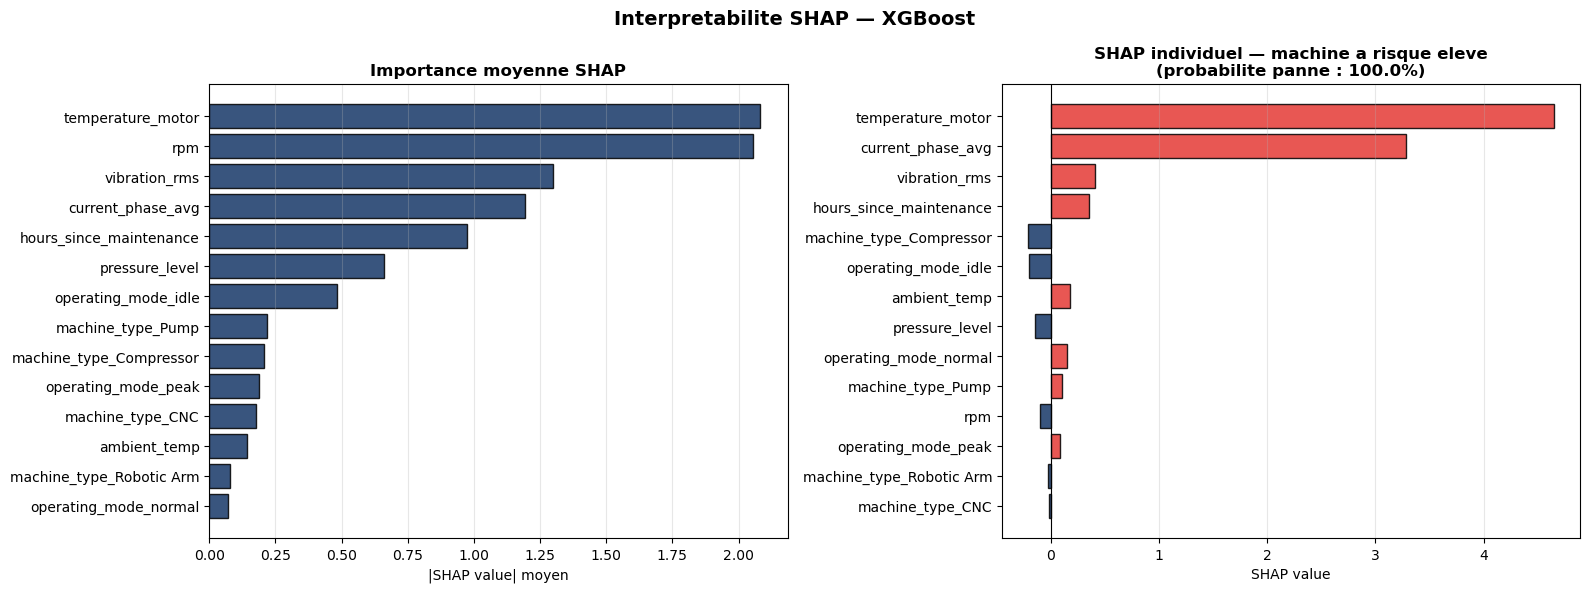

In [6]:
# CELLULE 4 - SHAP Bar plot + exemple individuel
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot importance moyenne SHAP
shap_mean = np.abs(shap_values).mean(axis=0)
indices = np.argsort(shap_mean)
axes[0].barh([FEATURE_NAMES[i] for i in indices],
             shap_mean[indices], color=COLOR_BLUE, edgecolor='black', alpha=0.85)
axes[0].set_title('Importance moyenne SHAP', fontweight='bold')
axes[0].set_xlabel('|SHAP value| moyen')
axes[0].grid(axis='x', alpha=0.3)

# Exemple individuel - machine à risque élevé
y_proba = xgb.predict_proba(X_test[:500])[:,1]
idx_high_risk = np.argmax(y_proba)
shap_single = shap_values[idx_high_risk]
indices_single = np.argsort(np.abs(shap_single))

colors = [COLOR_RED if v > 0 else COLOR_BLUE for v in shap_single[indices_single]]
axes[1].barh([FEATURE_NAMES[i] for i in indices_single],
             shap_single[indices_single], color=colors, edgecolor='black', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title(f'SHAP individuel — machine a risque eleve\n(probabilite panne : {y_proba[idx_high_risk]:.1%})', 
                  fontweight='bold')
axes[1].set_xlabel('SHAP value')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Interpretabilite SHAP — XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/shap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Le deuxième graphique explique la décision du modèle pour la machine la plus à risque. Les barres rouges montrent quels capteurs poussent vers la panne, les bleues vers saine. C'est ce qu'on appelle l'explicabilité locale